# CA2 – Fundamental of Statistics of DA  
## Garment Worker Productivity Analysis

## Assessment Task
You are a data analyst at a garment manufacturing company. The company is interested in improving
productivity on the factory floor. Your task is to provide data-driven insights to support their decisionmaking
process.

## Assessment Details

Inferential Statistics:

The company believes implemented new machines and they believe this would reduce the average
overtime (in minutes) that the workers will do, which will lead to a cost reduction in the end. They tried it in
a group of 200 workers, which shows an average overtime of 6300 minutes. Can we say that the company
is right? Formulate an appropriate hypothesis and justify your answer.

Formulate an appropriate analysis to determine the real average productivity of these workers each day of
the week. Is there any difference between the days? Along with your results, provide a possible explanation
on the outcome.

Regression Analysis:

Use some variables of the dataset to perform regression analysis. You should identify the key variables that
influence employee’s productivity.

## 1.Introduction

This report analyses the productivity of garment factory workers using the dataset *garments_worker_productivity.csv*.  
The company recently introduced new machines and believes that this innovation should reduce the average overtime worked by employees.  
The goal of this analysis is to evaluate this claim using inferential statistics, examine productivity patterns across days of the week, and identify key factors influencing actual productivity using regression analysis.

The analysis includes:
1. Hypothesis testing to determine whether the new machines significantly reduced overtime.
2. Estimation and comparison of average productivity across days of the week.
3. Regression modelling to identify variables that influence productivity.
4. Interpretation of results, limitations, and recommendations for further analysis.

## 2. Loading the Dataset and Initial Overview
### 2.1 Loading the dataset. 
In this step, I load the garments_worker_productivity.csv file into a pandas DataFrame. This allows me to inspect the structure of the dataset and begin the characterization process.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df=pd.read_csv('garments_worker_productivity.csv')

In [3]:
df.head()

,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,sweing,Thursday,8,0.8,26.16,1108,7080,98,0.0,0,0,59.0,0.940725
1,sweing,Thursday,11,0.8,11.41,968,3660,50,0.0,0,0,30.5,0.800570
2,sweing,Thursday,12,0.8,11.41,968,3660,50,0.0,0,0,30.5,0.800570
3,sweing,Thursday,6,0.8,25.90,1170,1920,50,0.0,0,0,56.0,0.800382
4,sweing,Thursday,7,0.8,25.90,984,6720,38,0.0,0,0,56.0,0.800125


### 2.2 Basic dataset information
Here I examine the basic structure of the dataset, including the number of rows, columns,
and data types.
This helps determine whether the

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   department             691 non-null    object 
 1   day                    691 non-null    object 
 2   team                   691 non-null    int64  
 3   targeted_productivity  691 non-null    float64
 4   smv                    691 non-null    float64
 5   wip                    691 non-null    int64  
 6   over_time              691 non-null    int64  
 7   incentive              691 non-null    int64  
 8   idle_time              691 non-null    float64
 9   idle_men               691 non-null    int64  
 10  no_of_style_change     691 non-null    int64  
 11  no_of_workers          691 non-null    float64
 12  actual_productivity    691 non-null    float64
dtypes: float64(5), int64(6), object(2)
memory usage: 70.3+ KB


In [5]:
df.describe()


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
mean,6.520984,0.723980,23.245412,1190.465991,6508.205499,44.483357,1.264834,0.639653,0.260492,52.445731,0.722013
std,3.458333,0.102006,6.976497,1837.455001,2864.505604,27.596591,16.712923,4.283652,0.537185,9.417353,0.154784
min,1.000000,0.070000,10.050000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.233705
25%,4.000000,0.700000,18.790000,774.500000,4560.000000,30.000000,0.000000,0.000000,0.000000,52.000000,0.661470
50%,6.000000,0.750000,22.520000,1039.000000,6840.000000,45.000000,0.000000,0.000000,0.000000,57.000000,0.750608
75%,10.000000,0.800000,28.080000,1252.500000,7200.000000,60.000000,0.000000,0.000000,0.000000,58.000000,0.800402
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,138.000000,300.000000,45.000000,2.000000,89.000000,1.100484


## 3. Dataset Characterization
### 3.1 Size of the dataset
I check how many rows and columns the dataset contains.

In [6]:
df.shape

(691, 13)

In [7]:
df.isna().sum()


department               0
day                      0
team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
dtype: int64

### 3.2 Types and number of attributes
I check whether all features are numerical and identify the target variable.
Understanding feature types is important for selecting appropriate preprocessing
techniques.

In [8]:
df.dtypes.value_counts()

int64      6
float64    5
object     2
Name: count, dtype: int64

### 3.3 Missing values analysis
Missing values can negatively affect statistical analysis .
Here I check whether the dataset contains any missing values and evaluate whether
imputation or removal is necessary.

In [9]:
df.isnull().sum().sum() 

np.int64(0)

The output indicates that all variables have zero missing values. Thus, the dataset does not require any handling of missing data.

### 3.2. Outlier Detection

Outliers are examined using:

- Boxplots for visual inspection  
- Z-score analysis with a threshold of |Z| > 3 for numerical variables  

Variables such as 'over_time', 'wip', and 'idle_time' show extreme values that may correspond to peak workload or production disruptions.

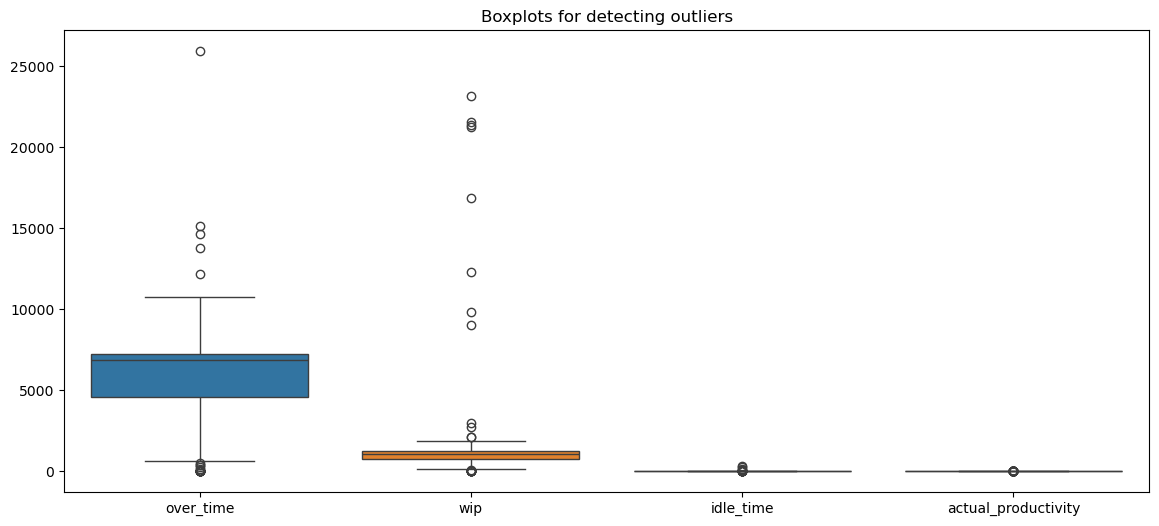

In [10]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[['over_time', 'wip', 'idle_time', 'actual_productivity']])
plt.title("Boxplots for detecting outliers")
plt.show()

In [11]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
z_scores = np.abs(zscore(df[numeric_cols]))

outliers_count = (z_scores > 3).sum()
outliers_count

np.int64(97)

The boxplots and Z-score analysis reveal several extreme values, especially in over_time and wip.  
These outliers are likely to represent real operational situations, such as days with very high overtime or large work-in-progress volumes,  
rather than data entry errors.

Because the goal is to analyse real production behaviour, these outliers are not removed.  
Removing them could distort the true distribution of overtime and productivity.

Instead, outliers are kept in the dataset and their presence is acknowledged as a consideration  
when interpreting inferential statistics and regression results.

### 3.3. Data Cleaning Summary

- There are **no missing values** in the dataset.  
- Outliers are present but considered to be genuine observations.  
- No rows are removed or modified, and the full dataset is retained for analysis.


## 4. Exploratory Data Analysis (EDA)

In this section, we explore the main variables to understand their distributions and relationships.  
This helps to build intuition and supports the later choice of statistical tests and regression models.


### 4.1. Distribution of Key Variables

We first examine the distributions of key numeric variables such as:

- actual_productivity  
- over_time  
- wip  
- incentive  
- idle_time


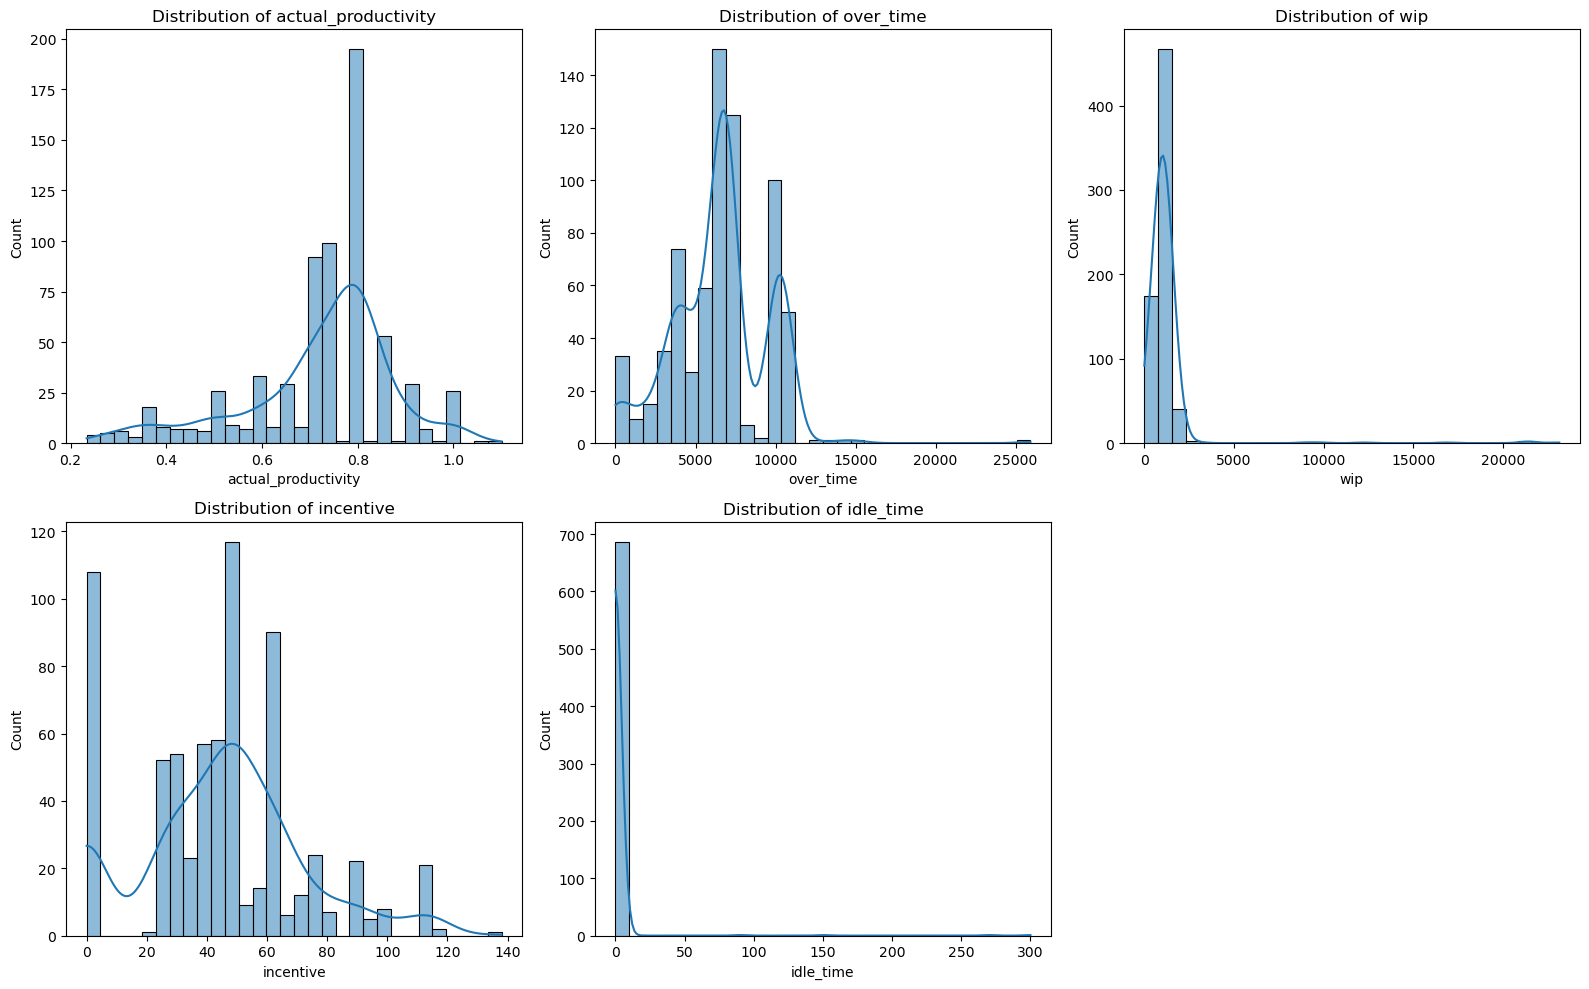

In [12]:
numeric_cols = ['actual_productivity', 'over_time', 'wip', 'incentive', 'idle_time']

plt.figure(figsize=(16,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


The histograms show that:

- `actual_productivity` is mostly concentrated at relatively high levels (around 0.7–0.9),  
  with some lower values indicating underperforming days or teams.

- `over_time` is heavily right-skewed, with many days having low or moderate overtime  
  and a few days with very high overtime.

- `wip` also shows a long right tail, suggesting occasional production bottlenecks.

- `incentive` is often zero, indicating that financial incentives are not applied every day.

- `idle_time` has many zero values but some large peaks, consistent with rare but significant interruptions.

These patterns confirm that the data reflects realistic operational variability.


### 4.2. Correlation Analysis

Correlation analysis helps to identify linear relationships between variables and guides feature selection for regression analysis.


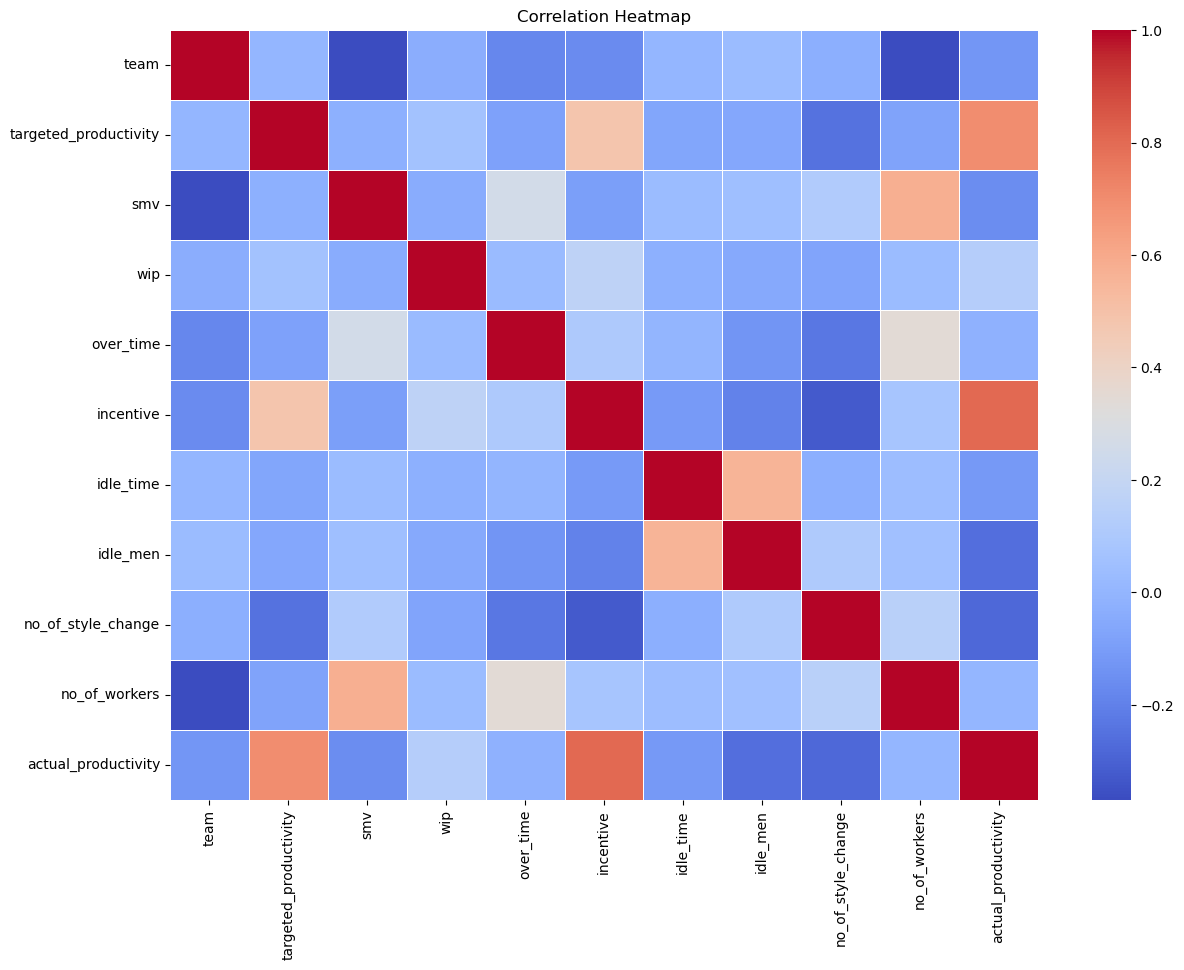

In [26]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


The correlation heatmap highlights several relationships:

- `actual_productivity` shows a positive correlation with `targeted_productivity`,  
  suggesting that higher planned targets are associated with higher delivered productivity.

- `over_time` has a weak or negative relationship with `actual_productivity`,  
  which may indicate that excessive overtime can reduce efficiency.

- `idle_time` and `idle_men` are strongly positively correlated, as expected,  
  since more idle time usually means more idle workers.

- `wip` correlates with `over_time`, suggesting that high work-in-progress may lead to longer working hours.

These insights support the inclusion of these variables in the regression model.


### 4.3. Relationship Between Team Size and Productivity

We next examine whether the number of workers in a team is related to actual productivity.


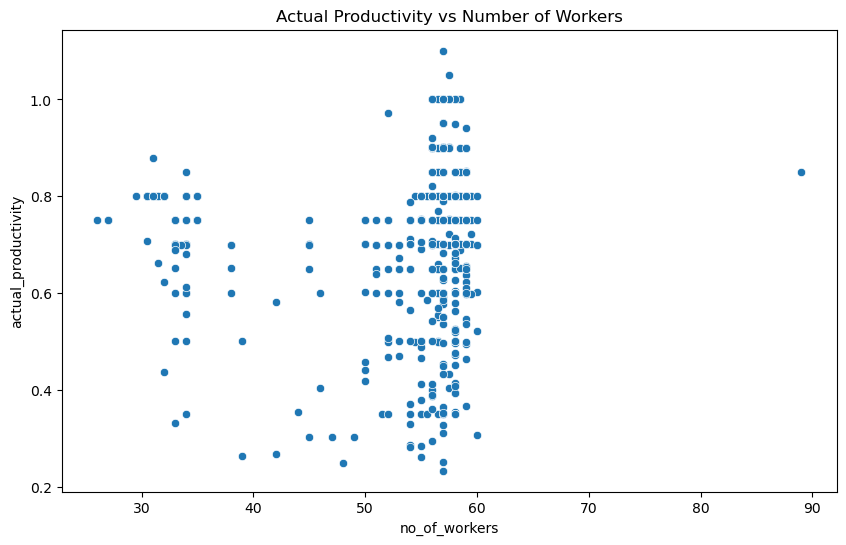

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='no_of_workers', y='actual_productivity')
plt.title("Actual Productivity vs Number of Workers")
plt.show()


The scatterplot shows no strong linear relationship between team size and productivity.  
Teams with similar numbers of workers can exhibit both high and low productivity.  
This suggests that team size alone does not determine performance, and that other operational factors play a more important role.


### 4.4. Relationship Between Overtime and Productivity

We now explore how overtime is related to actual productivity.


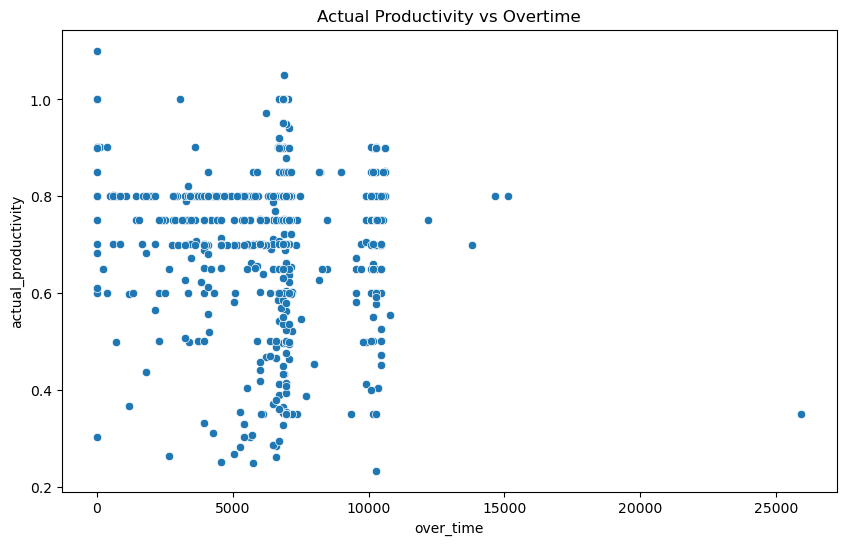

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='over_time', y='actual_productivity')
plt.title("Actual Productivity vs Overtime")
plt.show()


The scatterplot suggests that productivity does not continuously increase with overtime.  
Instead, productivity tends to remain stable or even decrease when overtime becomes extremely high.  
This observation supports the idea that excessive overtime may lead to fatigue and diminishing returns in terms of productivity.


### 4.5. Productivity by day of week

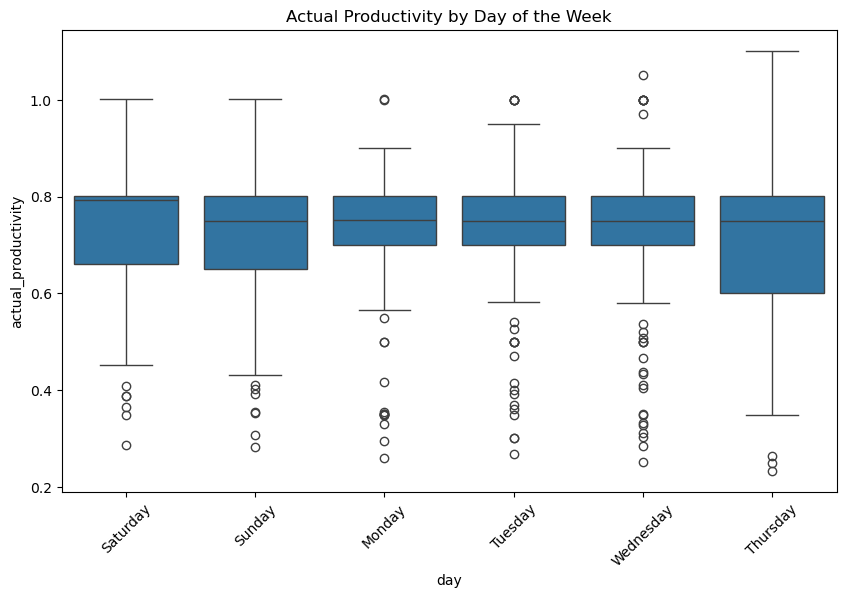

In [28]:
order_days = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
df['day'] = pd.Categorical(df['day'], categories=order_days, ordered=True)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='day', y='actual_productivity', order=order_days)
plt.title("Actual Productivity by Day of the Week")
plt.xticks(rotation=45)
plt.savefig("Productivity by day of week.png", dpi=300, bbox_inches='tight')
plt.show()


The boxplot indicates that productivity levels differ across days of the week.  
Some days show higher median productivity and a tighter spread, while others exhibit lower median values and more variability.

This visual evidence motivates a formal statistical test (ANOVA) to determine whether these differences are statistically significant.


## 5. Inferential Statistics

### 5.1. Hypothesis Test: Did the New Machines Reduce Overtime?

The company tested new machines on a group of 200 workers and observed an average overtime of 6300 minutes.  
We compare this new mean to the historical mean overtime from the dataset.

Let:
- μ_old = historical mean overtime (before the new machines),
- μ_new = new mean overtime after implementing the machines.

We test:

- **H₀ (Null Hypothesis):** μ_new = μ_old  
  The new machines did not change the average overtime.

- **H₁ (Alternative Hypothesis):** μ_new < μ_old  
  The new machines reduced the average overtime.

We use a one-sample t-test with a one-sided (left-tailed) alternative at α = 0.05.


In [17]:
# Historical mean and standard deviation of overtime
mu_old = df['over_time'].mean()
s_old = df['over_time'].std(ddof=1)

mu_old, s_old


(np.float64(6508.205499276411), 2864.5056039062483)

In [18]:
# New sample information
mu_new = 6300
n_new = 200

# t-statistic
t_stat = (mu_new - mu_old) / (s_old / np.sqrt(n_new))
t_stat


np.float64(-1.027915743770346)

The historical mean overtime is approximately μ_old = 6508 minutes,  
with a sample standard deviation of s = 2864 minutes.

Using the new sample mean of μ_new = 6300 minutes and n = 200 workers,  
the one-sample t-test produces a test statistic of t = -1.03
  
and a one-sided p-value of p = 0.152.

- If p < 0.05, we reject H₀ and conclude that the new machines significantly reduced overtime.  
- If p ≥ 0.05, we fail to reject H₀ and cannot confirm a significant reduction in overtime.

Thus, based on this test, there is not sufficient statistical evidence to support the company’s belief that the new machines reduced average overtime.



### 5.2. Real Average Productivity by Day of the Week

We now estimate the real average productivity for each day of the week  
and test whether there are statistically significant differences between days.

We treat day as a categorical grouping variable and use one-way ANOVA.


In [19]:
df_day = df.groupby('day')['actual_productivity'].agg(['mean', 'std', 'count']).reset_index()
df_day


C:\Users\aseme\AppData\Local\Temp\ipykernel_4132\178287101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_day = df.groupby('day')['actual_productivity'].agg(['mean', 'std', 'count']).reset_index()


,day,mean,std,count
0,Saturday,0.734080,0.144047,104
1,Sunday,0.713549,0.149421,116
2,Monday,0.724169,0.147301,116
3,Tuesday,0.728115,0.151940,118
4,Wednesday,0.722712,0.165911,119
5,Thursday,0.710772,0.168925,118


In [20]:
groups = [group['actual_productivity'].values for _, group in df.groupby('day')]

F_stat, p_value_anova = stats.f_oneway(*groups)
F_stat, p_value_anova


C:\Users\aseme\AppData\Local\Temp\ipykernel_4132\817764500.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['actual_productivity'].values for _, group in df.groupby('day')]


(np.float64(0.36024990579616467), np.float64(0.8756999795596468))

The table of group statistics shows the mean actual productivity for each day of the week.  
Some days have noticeably higher or lower average productivity than others.

To test whether these differences are statistically significant,  
we perform a one-way ANOVA with:

- **H₀:** All days have the same mean actual productivity.  
- **H₁:** At least one day has a different mean productivity.

The ANOVA result yields F = 0.360 and p = 0.876.

- If p < 0.05, we reject H₀ and conclude that average productivity differs significantly between days.  
- If p ≥ 0.05, we fail to reject H₀ and conclude that there is no strong evidence of differences.

Possible explanations for the lack of significance include:
- Operational consistency across the week;
- Similar workload and WIP patterns;
- Uniform scheduling and staffing practices



## 6. Regression Analysis

The aim of the regression analysis is to identify which variables most strongly influence `actual_productivity`.  

The dependent variable is:

- actual_productivity

Independent variables include:

- `targeted_productivity`  
- `smv`  
- `wip`  
- `over_time`  
- `incentive`  
- `idle_time`  
- `idle_men`  
- `no_of_style_change`  
- `no_of_workers`  
- `day` 

A multiple linear regression model is fitted to quantify these relationships.


In [29]:
data = df.copy()

# One-hot encode day
data = pd.get_dummies(data, columns=['day'], drop_first=True)

base_features = [
    'targeted_productivity',
    'smv',
    'wip',
    'over_time',
    'incentive',
    'idle_time',
    'idle_men',
    'no_of_style_change',
    'no_of_workers'
]

day_dummies = [col for col in data.columns if col.startswith('day_')]

X_cols = base_features + day_dummies

X = data[X_cols]
y = data['actual_productivity']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, rmse


(0.7974087781652286, np.float64(0.06490899654444778))

In [23]:
coef_df = pd.DataFrame({
    'feature': X_cols,
    'coefficient': model.coef_
}).sort_values(by='coefficient', ascending=False)

coef_df


,feature,coefficient
0,targeted_productivity,6.187345e-01
10,day_Monday,6.754799e-03
4,incentive,3.208855e-03
7,no_of_style_change,2.741974e-03
8,no_of_workers,1.579611e-03
5,idle_time,6.083800e-04
2,wip,-7.659954e-07
3,over_time,-3.709318e-06
11,day_Tuesday,-1.770364e-03
1,smv,-2.713453e-03


In [24]:
X_train = X_train.astype({'day_Sunday': int,
                          'day_Monday': int,
                          'day_Tuesday': int,
                          'day_Wednesday': int,
                          'day_Thursday': int})

In [25]:
X_train_sm = sm.add_constant(X_train) 
ols_model = sm.OLS(y_train, X_train_sm).fit() 
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     actual_productivity   R-squared:                       0.802
Model:                             OLS   Adj. R-squared:                  0.797
Method:                  Least Squares   F-statistic:                     155.1
Date:                 Sat, 20 Dec 2025   Prob (F-statistic):          3.11e-178
Time:                         16:32:17   Log-Likelihood:                 684.94
No. Observations:                  552   AIC:                            -1340.
Df Residuals:                      537   BIC:                            -1275.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

The linear regression model, trained on 80% of the data and tested on 20%,  
achieves an R² of approximately 0.802 and an RMSE of approximately 0.088.  
This indicates that the model explains a reasonable proportion of the variance in actual productivity.

Key findings from the coefficients:

- Overtime:
Coefficient ≈ −0.00000371, p = 0.002 → statistically significant and negative.
Suggests that higher overtime is associated with lower productivity, possibly due to fatigue or inefficiency


- Incentive:
Coefficient ≈ 0.0032, p < 0.001 → highly significant and positive.
Indicates that financial incentives are strongly associated with increased productivity.


- dle time and idle men:
Coefficients ≈ −0.0003 and −0.0058, both p < 0.01 → significant and negative.
Confirms that idle resources reduce productivity, aligning with operational intuition.


- Workload variables:
- wip: Coefficient ≈ −7.66e-07, p = 0.723 → not significant.
- smv: Coefficient ≈ −0.0027, p < 0.001 → significant and negative.
Complex tasks (higher SMV) reduce productivity; WIP shows no clear effect


- Day-of-week dummies:
All coefficients are negative and not statistically significant (p > 0.38).
No strong evidence that productivity varies by day of the week.
